In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 0.74  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length*1, 0., 0.)),
    ('H', (bond_length*2., 0., 0.)),
    ('H', (bond_length*3, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -2.09789961 Ha
FCI能量: -2.13888991 Ha


SpinOrbitalFermions 是 NetKet（特别是 netket ≥ v3.10 之后，或通过 netket.experimental）中用于描述具有自旋的费米子系统的希尔伯特空间（Hilbert space）类。它专为处理电子结构问题（如分子、固体中的多电子系统）而设计，天然支持泡利不相容原理和固定粒子数约束。

SpinOrbitalFermions 定义了一个由自旋轨道占据数构成的离散希尔伯特空间，每个自旋轨道只能被占据（1）或空（0），且满足：

费米子统计（自动通过占据数表示处理）
可选：固定总电子数、固定自旋向上/向下电子数


In [2]:
import itertools

# 排列组合
letters_alpha= [0,1,2,3]
letters_beta=  [4,5,6,7]
combinations_alpha = itertools.combinations(letters_alpha, 2)
combinations_beta =  itertools.combinations(letters_beta, 2)
clusters = list(combinations_alpha) + list(combinations_beta)
print(clusters)

[(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [3]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=4,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(2, 2)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
# cluster = [(0,1),(2,3)]
#
# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=clusters)
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [4]:
import jax
import jax.numpy as jnp
from flax import nnx

class FFN(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        """
        Construct a Feed-Forward Neural Network with a single hidden layer.

        Args:
            N: The number of input nodes (number of spins in the chain).
            alpha: The density of the hidden layer. The hidden layer will have
                N*alpha nodes.
            rngs: The random number generator seed.
        """
        self.alpha = alpha

        # We define a linear (or dense) layer with `alpha` times the number of input nodes
        # as output nodes.
        # We must pass forward the rngs object to the dense layer.
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):

        # we apply the linear layer to the input
        y = self.linear(x)

        # the non-linearity is a simple ReLu
        y = nnx.relu(y)

        # sum the output
        return jnp.sum(y, axis=-1)


# model = FFN(N=N, alpha=1, rngs=nnx.Rngs(2))

# vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

In [7]:
N = 8
ffnn_model = FFN(N=N, alpha=1, rngs=nnx.Rngs(2))
vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
exp_name = "h4_molecule_ffnn"

In [8]:
gs.run(300, out=exp_name)

  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:05<00:00, 53.61it/s, Energy=-2.098e+00 ± 7.850e-17 [σ²=3.155e-30, R̂=1.2374]]


(JsonLog('h4_molecule_ffnn', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.025464773178100586
   	Params: 0.0280458927154541,)

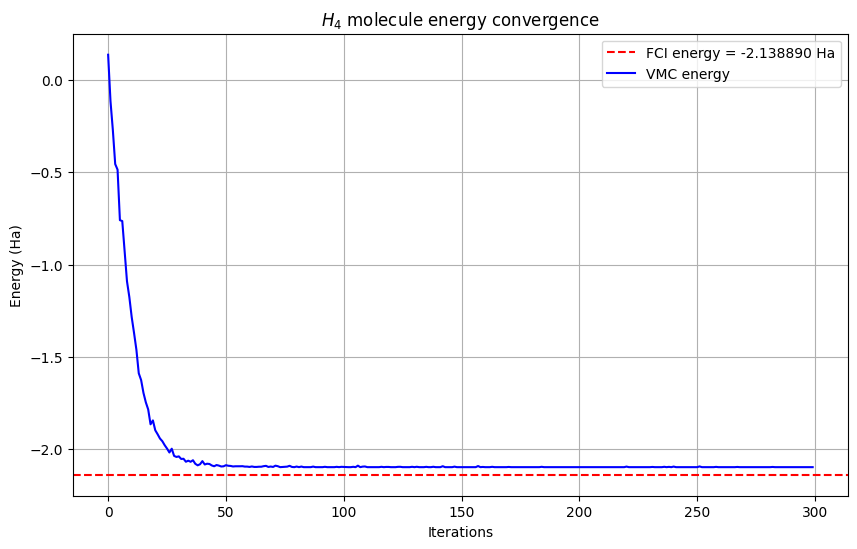


最终VMC能量: -2.09788200 Ha
与FCI能量误差: 0.04100791 Ha


In [10]:
############## 绘图 #################

# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("$H_4$ molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")
